In [1]:
import quantlib_sacha
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
from quantlib_sacha.quantlib.bonds.bond import Bond
from quantlib_sacha.quantlib.curves.curve import Curve, Curve_Interpolation

# 1. BOND INIT


In [3]:
bond_data = pd.read_excel("/Users/sachamace/PycharmProjects/PythonProject2/bond_example.xlsx")
bond_data.set_index("parameters", inplace=True)

In [4]:
bond_data

,value
parameters,
notional,100
start_date,2026-03-02 00:00:00
maturity,10
coupon_type,FIXED
coupon_rate,0.05
spread,0.001
coupon_frequency,4
reimbursement_price,100
day_count_convention,ACT/365


In [5]:
#Bond Parameters
notional = float(bond_data.loc["notional","value"])
start_date = pd.to_datetime(bond_data.loc["start_date","value"])
maturity = int(bond_data.loc["maturity","value"]) #years
coupon_type = str(bond_data.loc["coupon_type","value"]) # "ZC" or "FIXED" or "FLOAT" or "CONSTANT"
coupon_rate = float(bond_data.loc["coupon_rate","value"])
spread = float(bond_data.loc["spread","value"])
coupon_frequency = int(bond_data.loc["coupon_frequency","value"]) #1, 2, 3, or 4 coupon per year
reimbursement_price = float(bond_data.loc["reimbursement_price","value"])
day_count_convention = str(bond_data.loc["day_count_convention","value"])

bond = Bond(notional, start_date, maturity, coupon_type, coupon_rate, spread,coupon_frequency, reimbursement_price, day_count_convention)

# 2. CURVE DATA

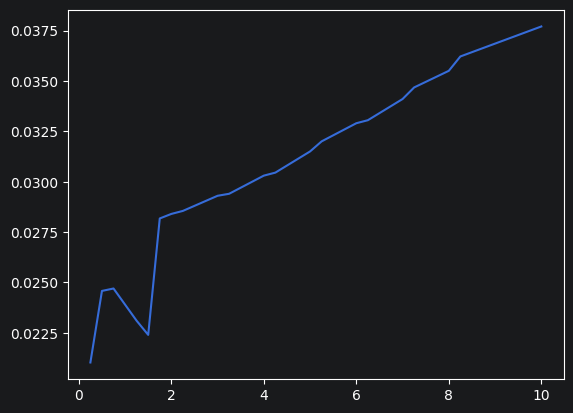

In [6]:
path = "/Users/sachamace/PycharmProjects/PythonProject2/Data for python project.xlsx"
curve_data = pd.read_excel(path, sheet_name = "Libor 3M Curve", nrows = 19)
initial_curve = Curve(curve_data)
period, rates_curve = Curve_Interpolation(initial_curve, maturity=maturity , payment_frequency=coupon_frequency).yield_curve()
plt.plot(period, rates_curve)

# 3. Day Count Ratio/Period

In [7]:
bond.day_count_fraction()

array([0.25205479, 0.25205479, 0.24931507, 0.24657534, 0.25205479,
       0.25205479, 0.24931507, 0.24931507, 0.25205479, 0.25205479,
       0.24931507, 0.24657534, 0.25205479, 0.25205479, 0.24931507,
       0.24657534, 0.25205479, 0.25205479, 0.24931507, 0.24657534,
       0.25205479, 0.25205479, 0.24931507, 0.24931507, 0.25205479,
       0.25205479, 0.24931507, 0.24657534, 0.25205479, 0.25205479,
       0.24931507, 0.24657534, 0.25205479, 0.25205479, 0.24931507,
       0.24657534, 0.25205479, 0.25205479, 0.24931507, 0.24931507])

# 4. Bond Pricer

In [8]:
start_dates, end_dates, period, coupon, rates_curve, DF, price = bond.pricer(rates_curve)
print("Price :", bond.pricer(rates_curve)[-1])
print("YTM :", round(bond.yield_to_maturity(rates_curve)*100,2),"%")
print("Duration :", round(bond.duration(rates_curve),2))
print("Sensitivity :", round(bond.sensitivity(rates_curve),2))
print("Convexity :", round(bond.convexity(rates_curve),2))

Price : 111.4586952004313
YTM : 3.68 %
Duration : 8.03
Sensitivity : 7.74
Convexity : 71.13


In [9]:
bond.schedule(rates_curve)

,Start_Dates,End_Dates,Period,Rates,DF,Coupon,Price,YTM,Duration,Sensitivity,Convexity
0,2026-03-02,2027-03-02,0.25,0.021030,0.994768,1.25,111.458695,0.036782,8.026357,7.741602,71.134028
1,2027-03-02,2028-03-02,0.50,0.024580,0.987833,1.25,NaN,NaN,NaN,NaN,NaN
2,2028-03-02,2029-03-02,0.75,0.024700,0.981784,1.25,NaN,NaN,NaN,NaN,NaN
3,2029-03-02,2030-03-02,1.00,0.023900,0.976658,1.25,NaN,NaN,NaN,NaN,NaN
4,2030-03-02,2031-03-02,1.25,0.023100,0.971811,1.25,NaN,NaN,NaN,NaN,NaN
5,2031-03-02,2032-03-02,1.50,0.022400,0.967229,1.25,NaN,NaN,NaN,NaN,NaN
6,2032-03-02,2033-03-02,1.75,0.028175,0.952448,1.25,NaN,NaN,NaN,NaN,NaN
7,2033-03-02,2034-03-02,2.00,0.028400,0.945459,1.25,NaN,NaN,NaN,NaN,NaN
8,2034-03-02,2035-03-02,2.25,0.028550,0.938500,1.25,NaN,NaN,NaN,NaN,NaN
9,2035-03-02,2036-03-02,2.50,0.028800,0.931297,1.25,NaN,NaN,NaN,NaN,NaN
